# 1. Identificação e Descrição do Problema

Título: Reconhecimento de 12 selos de mão do anime Naruto.

Integrantes: Luiz Cristóvão Rezende Poderoso, Jean Fonseca Santos e Ivanilton Vieira dos Santos.

Fonte dos Dados: [Naruto Hand Sign Dataset](https://www.kaggle.com/datasets/vikranthkanumuru/naruto-hand-sign-dataset). 

Objetivo: Reconhecer os 12 selos de mão do anime Naruto em imagens.

Atributo-Alvo: Categoria do selo de mão.

Atributos Preditivos: Matriz de pixels da imagem.

Tipo da Tarefa: Classificação.


# 2. Compreensão dos Dados



Instalação de bibliotecas necessárias para análise e comparação das imagens.

In [1]:
%pip install Pillow ImageHash

Note: you may need to restart the kernel to use updated packages.


Agora, importaremos as bibliotecas e declararemos as constantes necessárias.

In [6]:
import os
from PIL import Image
import imagehash

DATASET_PATH = os.path.join("dataset")
SIGNALS = ["bird", "boar", "dog", "dragon", "hare", "horse", "monkey", "ox", "ram", "rat", "snake", "tiger"]
IMG_DIFFERENCE_LIMIT = 5

Abaixo, declaramos as métricas gerais para análise do dataset.

In [3]:
valid_images_dict = dict()
resolutions_dict = dict()
total_count = 0
png_count = 0
jpg_count = 0
duplicates_count = 0
simmilar_count = 0

O objetivo do trecho seguinte é obter as informações acerca dos formatos das imagens, resolução e, utilizando a biblioteca `imagehash`, verificar se a imagem é duplicada ou extremamente semelhante a outra analisada anteriormente (Distância de Hamming <= 5). Também são armazenadas a quantidade de imagens úteis de cada selo de mão afim de analisar, posteriormente, o balanceamento dos dados. A resposta do trecho são os relatórios de cada selo de mão.

In [7]:
for signal in os.listdir(DATASET_PATH):
    signal_path = os.path.join(DATASET_PATH, signal)

    if (signal not in SIGNALS): 
        continue
    
    signal_total_count = 0
    signal_png_count = 0
    signal_jpg_count = 0
    signal_duplicates_count = 0
    signal_simmilar_count = 0

    signal_resolutions_count = dict()
    seen_hashes = set()

    for img_filename in os.listdir(signal_path):
        lower_img_name = img_filename.lower()

        # formato
        if lower_img_name.endswith(".png"): signal_png_count += 1
        elif lower_img_name.endswith(".jpg") or lower_img_name.endswith(".jpeg"): signal_jpg_count += 1
        signal_total_count += 1

        img_path = os.path.join(signal_path, img_filename)
        try:
            with Image.open(img_path) as img:
                # resoluções
                key = f"{img.size[0]}x{img.size[1]}"
                
                if key not in signal_resolutions_count: signal_resolutions_count[key] = 0
                if key not in resolutions_dict: resolutions_dict[key] = 0
                
                signal_resolutions_count[key] += 1
                resolutions_dict[key] += 1
                
                # duplicatas / semelhantes
                img_hash = imagehash.phash(img)
                
                is_duplicate = False
                is_similar = False

                for seen_hash in seen_hashes:
                    difference = img_hash - seen_hash
                    
                    if difference == 0:
                        is_duplicate = True
                        break
                    elif difference <= IMG_DIFFERENCE_LIMIT:
                        is_similar = True
                
                if is_duplicate:
                    signal_duplicates_count += 1
                elif is_similar:
                    signal_simmilar_count += 1
                else:
                    seen_hashes.add(img_hash)
        except Exception:
            pass

    print(f"{'-' * 25}\nSelo: {signal}\nTotal de Imagens: {signal_total_count}")

    print("\n---RESOLUÇÕES---")
    for key in signal_resolutions_count:
        length = signal_resolutions_count[key]
        print(f"{key}: {length}")

    print(f"\n---FORMATO---\nImagens PNG: {signal_png_count}\nImagens JPG: {signal_jpg_count}\nOutras imagens: {signal_total_count - signal_png_count - signal_jpg_count}")
    
    usable_images_count = signal_total_count - signal_duplicates_count - signal_simmilar_count
    valid_images_dict[signal] = usable_images_count

    print(f"\n---GERAL---\nDuplicatas: {signal_duplicates_count}\nSemelhantes: {signal_simmilar_count}\nVálidas: {usable_images_count}\n{'-' * 25}\n")
    
    total_count += signal_total_count
    png_count += signal_png_count
    jpg_count += signal_jpg_count
    duplicates_count += signal_duplicates_count
    simmilar_count += signal_simmilar_count

-------------------------
Selo: dog
Total de Imagens: 263

---RESOLUÇÕES---
640x480: 33
1280x720: 229
3264x1840: 1

---FORMATO---
Imagens PNG: 229
Imagens JPG: 34
Outras imagens: 0

---GERAL---
Duplicatas: 45
Semelhantes: 180
Válidas: 38
-------------------------

-------------------------
Selo: boar
Total de Imagens: 172

---RESOLUÇÕES---
1280x720: 149
640x480: 22
3264x1840: 1

---FORMATO---
Imagens PNG: 149
Imagens JPG: 23
Outras imagens: 0

---GERAL---
Duplicatas: 20
Semelhantes: 114
Válidas: 38
-------------------------

-------------------------
Selo: hare
Total de Imagens: 174

---RESOLUÇÕES---
1280x720: 149
640x480: 25

---FORMATO---
Imagens PNG: 148
Imagens JPG: 26
Outras imagens: 0

---GERAL---
Duplicatas: 39
Semelhantes: 108
Válidas: 27
-------------------------

-------------------------
Selo: ox
Total de Imagens: 169

---RESOLUÇÕES---
1280x720: 140
640x480: 28
3264x1840: 1

---FORMATO---
Imagens PNG: 140
Imagens JPG: 29
Outras imagens: 0

---GERAL---
Duplicatas: 59
Semelhan

Por último, para obter a análise geral aceca das imagens:

In [8]:
print(f"{'-' * 25}\nTotal\nTotal de Imagens: {total_count}")

print("\n---RESOLUÇÕES---")
for key in resolutions_dict:
    length = resolutions_dict[key]
    print(f"{key}: {length}")
    
print(f"\n---FORMATO---\nImagens PNG: {png_count}\nImagens JPG: {jpg_count}\nOutras imagens: {total_count - png_count - jpg_count}")

valid_images_count = sum(valid_images_dict.values())
max_signal = max(valid_images_dict, key=valid_images_dict.get)
min_signal = min(valid_images_dict, key=valid_images_dict.get)

print(f"\n---DISTRIBUIÇÃO DO ATRIBUTO-ALVO (IMAGENS ÚTEIS)---")
print(f"Desbalanceamento: o sinal {max_signal} possui a maior quantidade de imagens úteis: {valid_images_dict[max_signal]}. Já {min_signal} possui a menor quantidade, com {valid_images_dict[min_signal]}.\nA quantidade de imagens válidas por sinal é:")
for signal, count in valid_images_dict.items():
    print(f"{signal}: {count} imagens")

print(f"\n---GERAL---\nDuplicatas: {duplicates_count}\nSemelhantes: {simmilar_count}\nUtilizáveis: {valid_images_count}\n{'-' * 25}\n")

-------------------------
Total
Total de Imagens: 1960

---RESOLUÇÕES---
640x480: 329
1280x720: 1620
3264x1840: 11

---FORMATO---
Imagens PNG: 1619
Imagens JPG: 341
Outras imagens: 0

---DISTRIBUIÇÃO DO ATRIBUTO-ALVO (IMAGENS ÚTEIS)---
Desbalanceamento: o sinal dog possui a maior quantidade de imagens úteis: 38. Já rat possui a menor quantidade, com 19.
A quantidade de imagens válidas por sinal é:
dog: 38 imagens
boar: 38 imagens
hare: 27 imagens
ox: 28 imagens
tiger: 30 imagens
rat: 19 imagens
bird: 21 imagens
dragon: 33 imagens
monkey: 31 imagens
horse: 32 imagens
ram: 22 imagens
snake: 32 imagens

---GERAL---
Duplicatas: 420
Semelhantes: 1189
Utilizáveis: 351
-------------------------



O relatório final aponta a existência de 1960 imagens no dataset original. As imagens estão em 3 resoluções diferentes: `640x480`, `1280x720` e `3264x1840`, sendo majoritariamente (1620) em `1280x720`. Ademais, as imagens, em sua maioria (1619 imagens), são `PNG`, já o restante em `JPG`. Além disso, há uma discrepência considerável entre as imagens úteis dos sinais: enquanto `dog` e `boar` possui 38, `rat` tem 19. Por fim, o dataset possui uma quantidade preocupante de imagens duplicadas (Distância de Hamming igual a 0): 420, e uma ainda mais preocupante de semelhantes (Distância de Hamming menor ou igual a 5): 1189. Os problemas apresentados aqui serão tratados no pré-processamento dos dados.

# 3. Analise Exploratória

Abaixo realizamos a instalação e importação do matplotlib para gerar os gráficos.

In [ ]:
%pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

#### Distruibuição de imagens úteis por selo de mão

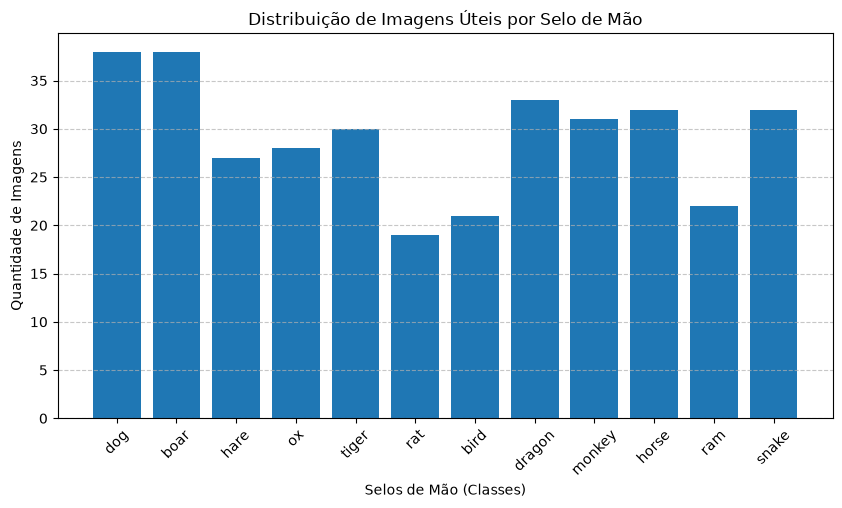

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(valid_images_dict.keys(), valid_images_dict.values())
plt.title('Distribuição de Imagens Úteis por Selo de Mão')
plt.xlabel('Selos de Mão (Classes)')
plt.ylabel('Quantidade de Imagens')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A visualização do histograma acima evidencia a disparidade entre a frequência de diferentes selos de mão. O desbalanceamento é tal que algumas classes possuem o dobro de imagens úteis do que outras. Devido a esse fator e à baixa quantidade de imagens, a adição de novas imagens será realizada no dataset.

#### Relação entre atributos e alvo

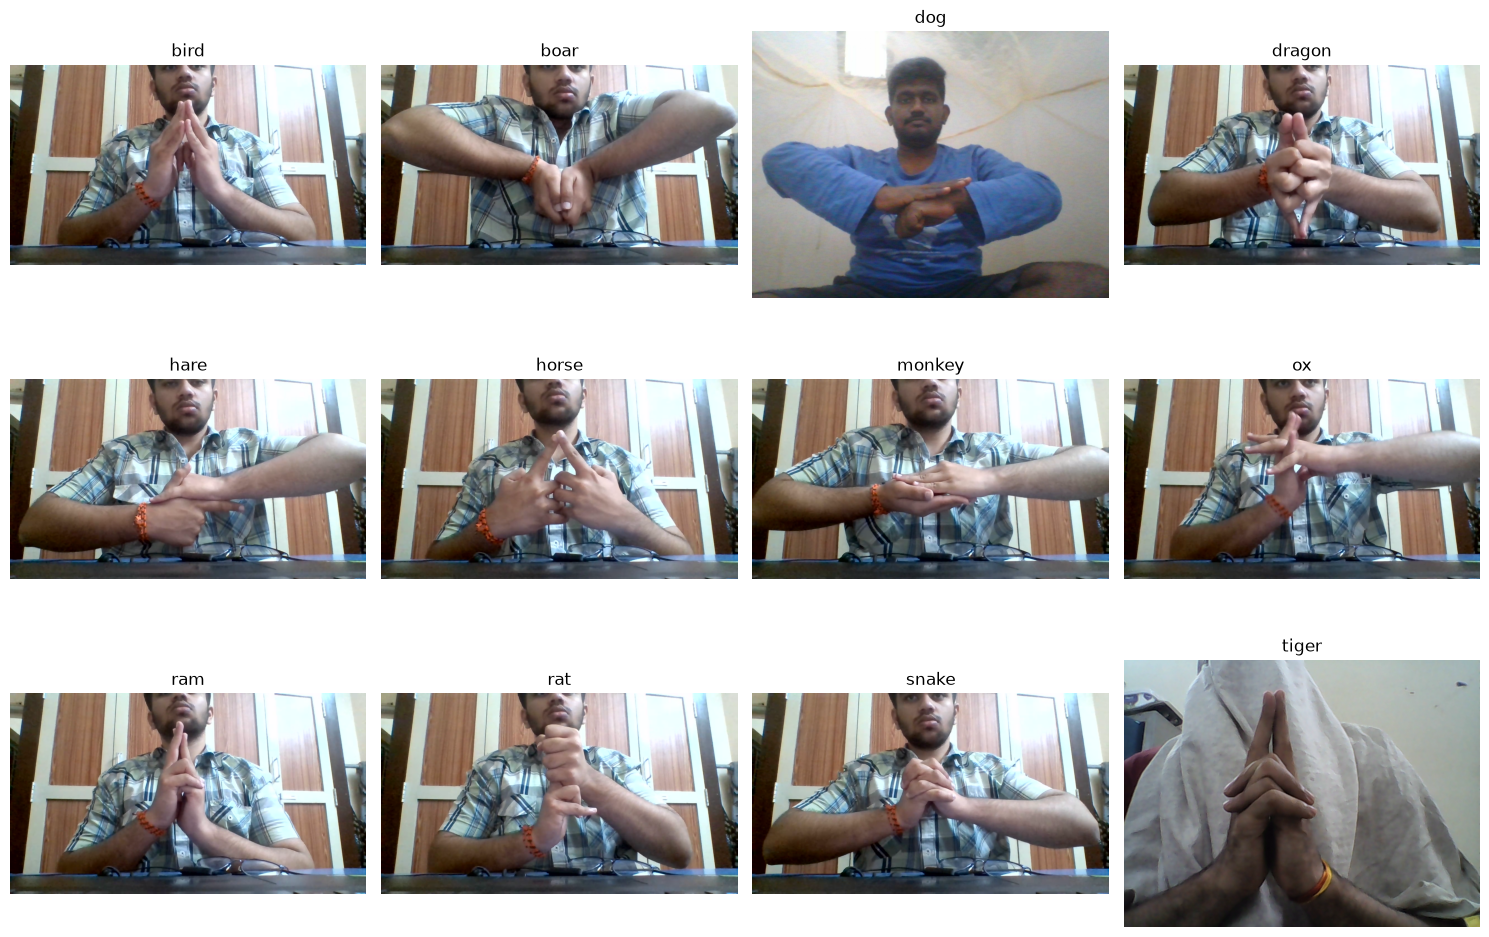

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, signal in enumerate(SIGNALS):
    signal_path = os.path.join(DATASET_PATH, signal)
    
    for img_name in os.listdir(signal_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(signal_path, img_name)
            img = Image.open(img_path)
            
            axes[i].imshow(img)
            axes[i].set_title(signal)
            axes[i].axis('off')
            break

plt.tight_layout()
plt.show()

Devido à natureza do dataset, os atributos preditivos consistem nas matrizes de pixels que compõem as imagens. Acima é possível observar uma imagem retirada do dataset de cada selo de mão. Essa plotagem demonstra a forma com que as imagens são colhidas, sendo o selo de mão ocupante de parte pequena da imagem.

#### Histogramas de intensidade de pixels

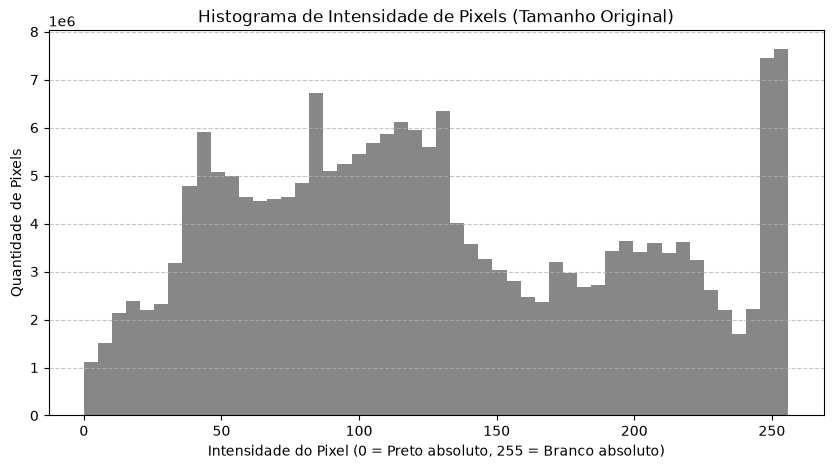

In [ ]:
import numpy as np

IMG_PER_SIGNAL = 20 

def pixels_intensity_histogram(size: int = 0):
    bins = 50
    histogram = np.zeros(bins)
    bar_limits = np.linspace(0, 256, bins + 1)

    for signal in SIGNALS:
        signal_path = os.path.join(DATASET_PATH, signal)
        
        if not os.path.exists(signal_path):
            continue
            
        count = 0
        for img_name in os.listdir(signal_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(signal_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        if size > 0: img.thumbnail((size, size)) 
                        gray_img = img.convert('L')
                        
                        pixels = np.array(gray_img).flatten()
                        
                        local_count, _ = np.histogram(pixels, bins=bar_limits)
                        histogram += local_count
                        
                except Exception:
                    pass
                
                count += 1
                if count >= IMG_PER_SIGNAL:
                    break 

    plt.figure(figsize=(10, 5))

    bar_width = 256 / bins
    bar_center = bar_limits[:-1] + bar_width / 2

    plt.bar(bar_center, histogram, width=bar_width, color='dimgray', alpha=0.8)

    if size == 0:
        plt.title(f'Histograma de Intensidade de Pixels (Tamanho Original)')
    else:
        plt.title(f'Histograma de Intensidade de Pixels {size}x{size}')

    plt.xlabel('Intensidade do Pixel (0 = Preto absoluto, 255 = Branco absoluto)')
    plt.ylabel('Quantidade de Pixels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

pixels_intensity_histogram()

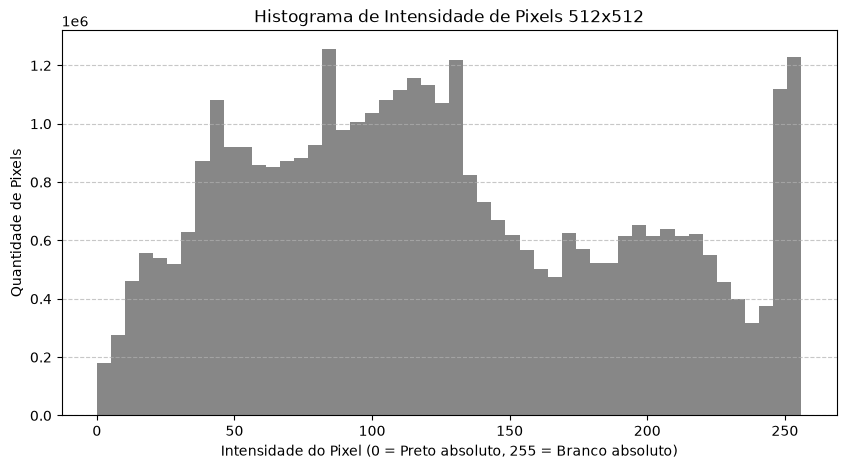

In [33]:
pixels_intensity_histogram(512)

Através dos histogramas de intensidade de pixels, é possível notar que o dataset apresenta picos de superexposição (concentração de pixels próximos ao limite de 255), o que pode afetar a classificação dos selos de mão por parte dos modelos. Apesar disso, ao reduzir a resolução das imagens (segundo histograma), a concentração de pixels brancos diminuiu consideravelmente, o que pode contribuir para a mitigação desse problema.

# 4. Pré-processamento

## 4.1 Novas imagens

As imagens do dataset, além de escassas, apresentaram um baixo padrão de qualidade, sendo muitos delas frames consecutivos de um mesmo vídeo (quase nenhuma variação entre elas). Devido a isso, foi necessário adicionar novas imagens ao conjunto. Primeiro, a equipe desenvolveu um script que extrai imagens de um vídeo a cada 30 frames (veja o diretório `scripts/extracao`), já inserindo-as nas pastas corretas do dataset. Os vídeos foram gravados de forma com que diversas rotações e posições de um mesmo selo fossem obtidos. Depois, os integrantes da equipe gravaram vídeos fazendo os selos de mão em diferentes ambientes com diferentes iluminações. Também, foi indispensável a ajuda de outras pessoas na gravação desses vídeos, gerando diversidade suficiente para um modelo proveitoso. É fundamental destacar que houve revisão de cada uma das imagens, visando excluir a presença de registros borrados ou de baixa qualidade.

## 4.2 Redimensionamento das imagens

Antes de irem para o modelo, as imagens utilizadas foram redimensionadas para uma matriz fixa de pixels, com o objetivo de uniformizar os dados de entrada. Uma consequência positiva disso, é a normalização da intensidade dos pixels como visto anteriormente no histograma de intensidade de pixels.

## 4.3 Planificação das matrizes

As matrizes de pixels foram reorganizadas de modo que se tornassem matrizes unidimensionais, facilitando a utilização delas nos algoritmos requisitados.

# 5. Separação dos Dados

Os dados foram separados com a seguinte proporção: 80% para os dados de treinamento e 20% para os dados de teste. Essa proporção foi escolhida por ser a padrão para treinamento de classificação de imagens para a quantidade de dados que possuímos. 

Para seguir essa divisão, os dados são divididos em subpastas dentro dos sinais de mão, onde cada subpasta é nomeada como uma identificador único por vídeo de origem. Assim, 80% das subpastas são utilizadas para treinamento e 20% para teste. Isso evita que imagens de um mesmo vídeo sejam utilizadas para teste e treinamento simultânemante, o que poderia gerar uma taxa de acerto alta artificialmente devido à semelhança dos dados. 

# 6. Modelagem

# 7. Avaliação e Discussão